(200, 2, 128, 128)


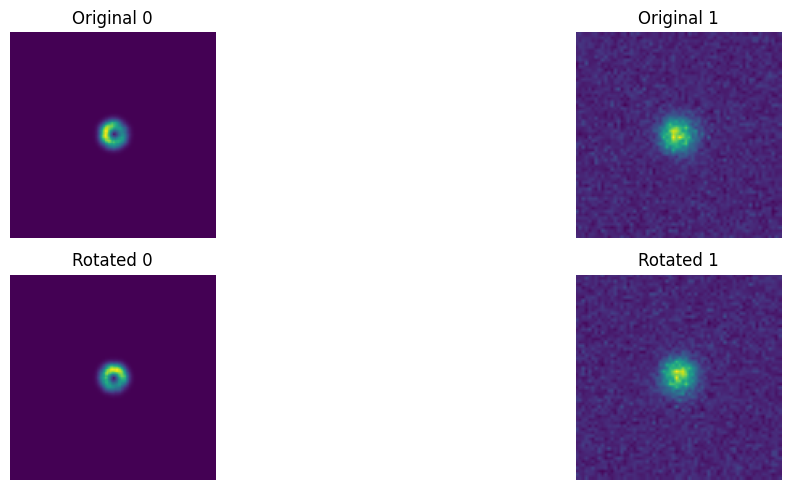

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# 读取数据
data = np.load("Type_A_SHELL_200_128_SR4poissonexcess.npy")

sample = data[14]

# 先逆时针90°
sample_rot90 = np.rot90(sample, k=1, axes=(1, 2))

# 再顺时针45°（即 angle=-45）
sample_rot45 = np.empty_like(sample_rot90)

for i in range(sample_rot90.shape[0]):
    sample_rot45[i] = rotate(
        sample_rot90[i],
        angle=-45,          # 顺时针45°
        reshape=False,      # 保持128×128大小
        order=1,            # 双线性插值
        mode='constant',
        cval=0              # 边缘补0
    )

# 可视化
fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i in range(2):
    axes[0, i].imshow(sample[i], origin='lower', cmap='viridis')
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(sample_rot90[i], origin='lower', cmap='viridis')
    axes[1, i].set_title(f"90° CCW")
    axes[1, i].axis("off")

    axes[2, i].imshow(sample_rot45[i], origin='lower', cmap='viridis')
    axes[2, i].set_title(f"90° CCW + 45° CW")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()